In [1]:
%%capture
def running_in_colab():
    try:
        import google.colab  # type: ignore[import]  # noqa: F401
        return True
    except ImportError:
        return False

if running_in_colab():
    print("Colab detected → installing deps...")
    !pip install -q git+https://github.com/thatmariia/macro-eeg-model.git@erps


# Config

## Brain stuff

### Nodes (brain regions)

In [2]:
from macro_eeg.core import Node, NodesCollection

node_fl = Node(name="frontal lobe", code="FL")
node_pl = Node(name="parietal lobe", code="PL")
node_ol = Node(name="occiptal lobe", code="OL")
node_tl = Node(name="temporal lobe", code="TL")
node_t = Node(name="thalamus", code="T")
nodes = [node_fl, node_pl, node_ol, node_tl, node_t]

nodes_collection = NodesCollection(nodes=nodes)

### Edges

In [3]:
from macro_eeg.core import Edge, EdgesCollection

edge_fl_pl, edge_pl_fl  = Edge(src=node_fl, dst=node_pl).with_reversed()
edge_fl_ol, edge_ol_fl  = Edge(src=node_fl, dst=node_ol).with_reversed()
edge_fl_tl, edge_tl_fl  = Edge(src=node_fl, dst=node_tl).with_reversed()
edge_fl_t, edge_t_fl    = Edge(src=node_fl, dst=node_t).with_reversed()
edge_pl_ol, edge_ol_pl  = Edge(src=node_pl, dst=node_ol).with_reversed()
edge_pl_tl, edge_tl_pl  = Edge(src=node_pl, dst=node_tl).with_reversed()
edge_pl_t, edge_t_pl    = Edge(src=node_pl, dst=node_t).with_reversed()
edge_ol_tl, edge_tl_ol  = Edge(src=node_ol, dst=node_tl).with_reversed()
edge_ol_t, edge_t_ol    = Edge(src=node_ol, dst=node_t).with_reversed()
edge_tl_t, edge_t_tl    = Edge(src=node_tl, dst=node_t).with_reversed()

### Distances

In [4]:
from macro_eeg.core import EdgeDistance

dist_fl_pl, dist_pl_fl  = EdgeDistance(edge=edge_fl_pl, distance=87.694797).with_reversed()
dist_fl_ol, dist_ol_fl  = EdgeDistance(edge=edge_fl_ol, distance=79.780942).with_reversed()
dist_fl_tl, dist_tl_fl  = EdgeDistance(edge=edge_fl_tl, distance=59.550866).with_reversed()
dist_fl_t, dist_t_fl    = EdgeDistance(edge=edge_fl_t,  distance=50.410222).with_reversed()
dist_pl_ol, dist_ol_pl  = EdgeDistance(edge=edge_pl_ol, distance=85.579993).with_reversed()
dist_pl_tl, dist_tl_pl  = EdgeDistance(edge=edge_pl_tl, distance=73.568051).with_reversed()
dist_pl_t, dist_t_pl    = EdgeDistance(edge=edge_pl_t,  distance=75.444747).with_reversed()
dist_ol_tl, dist_tl_ol  = EdgeDistance(edge=edge_ol_tl, distance=89.062507).with_reversed()
dist_ol_t, dist_t_ol    = EdgeDistance(edge=edge_ol_t,  distance=94.531546).with_reversed()
dist_tl_t, dist_t_tl    = EdgeDistance(edge=edge_tl_t,  distance=65.734991).with_reversed()
distances = [
    dist_fl_pl, dist_pl_fl,
    dist_fl_ol, dist_ol_fl,
    dist_fl_tl, dist_tl_fl,
    dist_fl_t, dist_t_fl,
    dist_pl_ol, dist_ol_pl,
    dist_pl_tl, dist_tl_pl,
    dist_pl_t, dist_t_pl,
    dist_ol_tl, dist_tl_ol,
    dist_ol_t, dist_t_ol,
    dist_tl_t, dist_t_tl
]

distances_collection = EdgesCollection.from_edges(distances, nodes_collection=nodes_collection)

### Baseline connectivity

In [5]:
from macro_eeg.core import EdgeConnectivity

cw_fl_pl, cw_pl_fl  = EdgeConnectivity(edge=edge_fl_pl, weight=0.80).with_reversed()
cw_fl_ol, cw_ol_fl  = EdgeConnectivity(edge=edge_fl_ol, weight=0.80).with_reversed()
cw_fl_tl, cw_tl_fl  = EdgeConnectivity(edge=edge_fl_tl, weight=0.30).with_reversed()
cw_fl_t, cw_t_fl    = EdgeConnectivity(edge=edge_fl_t,  weight=0.10).with_reversed()
cw_pl_ol, cw_ol_pl  = EdgeConnectivity(edge=edge_pl_ol, weight=1.20).with_reversed()
cw_pl_tl, cw_tl_pl  = EdgeConnectivity(edge=edge_pl_tl, weight=0.75).with_reversed()
cw_pl_t, cw_t_pl    = EdgeConnectivity(edge=edge_pl_t,  weight=0.10).with_reversed()
cw_ol_tl, cw_tl_ol  = EdgeConnectivity(edge=edge_ol_tl, weight=0.80).with_reversed()
cw_ol_t, cw_t_ol    = EdgeConnectivity(edge=edge_ol_t,  weight=0.10).with_reversed()
cw_tl_t, cw_t_tl    = EdgeConnectivity(edge=edge_tl_t,  weight=0.10).with_reversed()
connectivity = [
    cw_fl_pl, cw_pl_fl,
    cw_fl_ol, cw_ol_fl,
    cw_fl_tl, cw_tl_fl,
    cw_fl_t, cw_t_fl,
    cw_pl_ol, cw_ol_pl,
    cw_pl_tl, cw_tl_pl,
    cw_pl_t, cw_t_pl,
    cw_ol_tl, cw_tl_ol,
    cw_ol_t, cw_t_ol,
    cw_tl_t, cw_t_tl
]

connectivity_collection = EdgesCollection.from_edges(connectivity, nodes_collection=nodes_collection)

### Axon diameter distribution & delay pdf

In [6]:
from macro_eeg.core import DiameterDist

diameter_dist = DiameterDist(
    shape=-0.25,
    scale=0.09,
    location=0.25,
)

In [7]:
from macro_eeg.utils import get_delay_pdf_fn

delay_pdf_fn = get_delay_pdf_fn(diameter_dist)

## Stimuli with functions

In [8]:
from macro_eeg.core import Stimulus, StimulusNodeTarget, EdgeConnectivityCoef
from macro_eeg.utils import get_stimulus_fn, get_time_fn

### P100

In [ ]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_ol_pl, coef=1.25),
    EdgeConnectivityCoef(edge=edge_ol_tl, coef=1.15),
    EdgeConnectivityCoef(edge=edge_pl_ol, coef=0.90),
    EdgeConnectivityCoef(edge=edge_fl_pl, coef=0.95),
]
edge_coeffs_collection = EdgesCollection.from_edges(edge_coeffs, nodes_collection=nodes_collection)

stimulus1 = Stimulus(
    name="p100",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=0.05),
        StimulusNodeTarget(node=node_pl, coef=0.35),
        StimulusNodeTarget(node=node_ol, coef=1.30),
        StimulusNodeTarget(node=node_tl, coef=0.25),
    ],
    onset_ms=get_time_fn(time=(80, 120), strategy="random"),
    duration_ms=35,
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=1.0, strategy="step"),
)

### N200

In [10]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_fl_pl, coef=1.20),
    EdgeConnectivityCoef(edge=edge_pl_fl, coef=1.15),
    EdgeConnectivityCoef(edge=edge_ol_pl, coef=1.05),
    EdgeConnectivityCoef(edge=edge_ol_tl, coef=0.95),
    EdgeConnectivityCoef(edge=edge_pl_ol, coef=0.95),
]
edge_coeffs_collection = EdgesCollection.from_edges(edge_coeffs, nodes_collection=nodes_collection)

stimulus2 = Stimulus(
    name="n200",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=0.60),
        StimulusNodeTarget(node=node_pl, coef=0.60),
        StimulusNodeTarget(node=node_ol, coef=0.40),
        StimulusNodeTarget(node=node_tl, coef=0.30),
    ],
    onset_ms=get_time_fn(time=(180, 250), strategy="random"),
    duration_ms=80,
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=-0.90, strategy="step"),
)

### P300

In [11]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_pl_fl, coef=1.20),
    EdgeConnectivityCoef(edge=edge_fl_pl, coef=1.10),
    EdgeConnectivityCoef(edge=edge_pl_t,  coef=1.15),
    EdgeConnectivityCoef(edge=edge_ol_pl, coef=0.90),
    EdgeConnectivityCoef(edge=edge_pl_ol, coef=0.95),
]
edge_coeffs_collection = EdgesCollection.from_edges(edge_coeffs, nodes_collection=nodes_collection)

stimulus3 = Stimulus(
    name="p300",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=0.60),
        StimulusNodeTarget(node=node_pl, coef=1.20),
        StimulusNodeTarget(node=node_ol, coef=0.20),
        StimulusNodeTarget(node=node_tl, coef=0.40),
        StimulusNodeTarget(node=node_t, coef=0.40),
    ],
    onset_ms=get_time_fn(time=(320, 400), strategy="random"),
    duration_ms=200,
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=1.10, strategy="step"),
)

In [ ]:
stimuli = [stimulus1, stimulus2, stimulus3]

## Stimuli with functions

### P100

In [ ]:
stimulus1_functions = Stimulus(
    name=stimulus1.name,
    node_targets=stimulus1.node_targets,
    onset_ms=stimulus1.onset_ms,
    duration_ms=stimulus1.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus1.stimulus_fn,
)

### N200

In [ ]:
stimulus2_functions = Stimulus(
    name=stimulus2.name,
    node_targets=stimulus2.node_targets,
    onset_ms=stimulus2.onset_ms,
    duration_ms=stimulus2.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus2.stimulus_fn,
)

### P300

In [ ]:
stimulus3_functions = Stimulus(
    name=stimulus3.name,
    node_targets=stimulus3.node_targets,
    onset_ms=stimulus3.onset_ms,
    duration_ms=stimulus3.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus3.stimulus_fn,
)

## Stimuli with connectivity

### P100

In [ ]:
stimulus1_connectivity = Stimulus(
    name=stimulus1.name,
    node_targets=stimulus1.node_targets,
    onset_ms=stimulus1.onset_ms,
    duration_ms=stimulus1.duration_ms,
    edge_coeffs=stimulus1.edge_coeffs,
    stimulus_fn=None,
)

### N200

In [ ]:
stimulus2_connectivity = Stimulus(
    name=stimulus2.name,
    node_targets=stimulus2.node_targets,
    onset_ms=stimulus2.onset_ms,
    duration_ms=stimulus2.duration_ms,
    edge_coeffs=stimulus2.edge_coeffs,
    stimulus_fn=None,
)

### P300

In [ ]:
stimulus3_connectivity = Stimulus(
    name=stimulus3.name,
    node_targets=stimulus3.node_targets,
    onset_ms=stimulus3.onset_ms,
    duration_ms=stimulus3.duration_ms,
    edge_coeffs=stimulus3.edge_coeffs,
    stimulus_fn=None,
)

In [ ]:
stimuli_connectivity = [
    stimulus1_connectivity,
    stimulus2_connectivity,
    stimulus3_connectivity,
]

## Simulation params & noise

In [13]:
from macro_eeg.core import SimulationParams

sim_params = SimulationParams(
    sample_rate=1000,
    t_lags=300,
    t_secs=400,
    t_burnin=10
)

In [14]:
from macro_eeg.utils import get_noise_fn

noise_fn = get_noise_fn(
    std=2.0,
    strategy="white"
)

# Simulation

In [15]:
import matplotlib.pyplot as plt

## Weighted lag distribution effects

In [ ]:
from macro_eeg.simulation import compute_lag_effects

lag_base, lags_stim = compute_lag_effects(
    base_connectivity=connectivity_collection,
    distances=distances_collection,
    delay_pdf_fn=delay_pdf_fn,
    sim_params=sim_params,
    stimuli=stimuli,
    make_base_stationary=True,
    make_stim_stationary=False,
    shrink=0.5,
    show_progress=True,
)

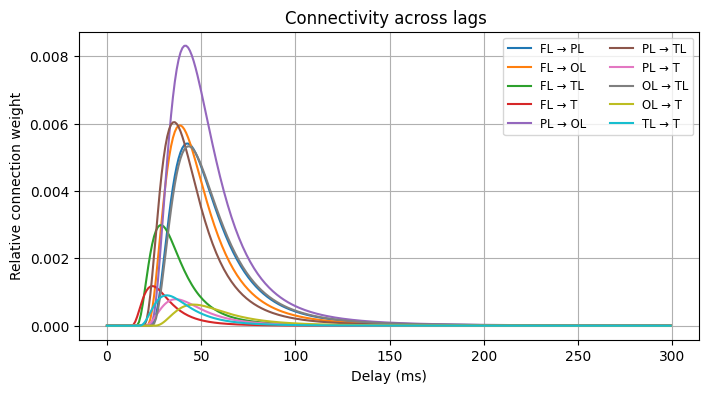

In [17]:
from macro_eeg.viz import plot_lag_connectivity

fig, ax = plt.subplots(figsize=(8, 4))

fig, ax = plot_lag_connectivity(
    lag_connectivity=lag_base,
    node_names=[node.code for node in nodes_collection.nodes],
    plot_name=None,
    ax=ax
)

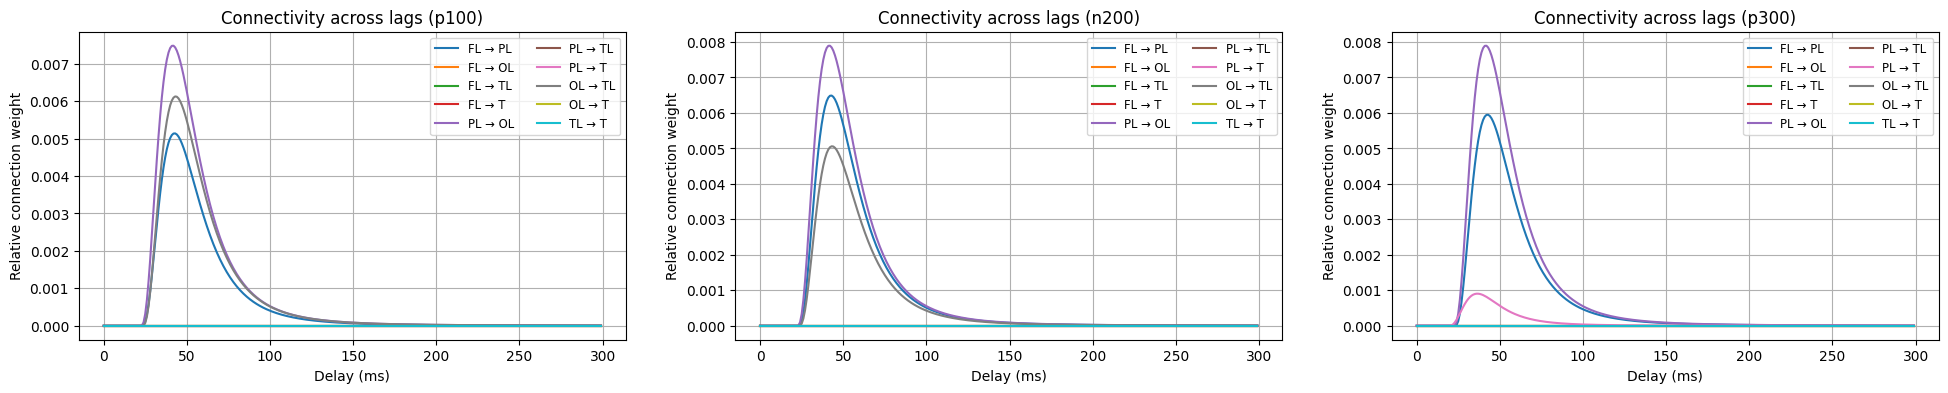

In [18]:
if lags_stim:
    fig, axes = plt.subplots(1, len(lags_stim), figsize=(8 * len(lags_stim), 4))
    axes = axes.ravel()

    for i, ax in enumerate(axes):
        plot_lag_connectivity(
            lag_connectivity=lags_stim[i],
            node_names=[node.code for node in nodes_collection.nodes],
            plot_name=stimuli[i].name,
            ax=ax
        )

## VAR simulation

In [ ]:
from macro_eeg.simulation import simulate_var

data = simulate_var(
    noise_fn=noise_fn,
    nodes=nodes_collection,
    params=sim_params,
    lag_base=lag_base,
    lags_stim=lags_stim,
    stimuli=stimuli,
    nr_trials=80,
    show_progress=True,
    cooldown=45
)

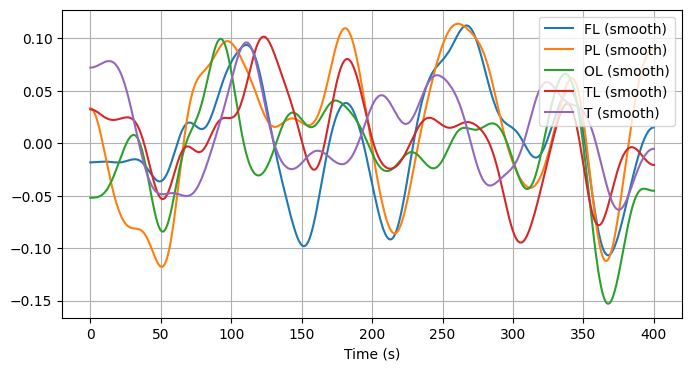

In [24]:
from macro_eeg.viz import plot_simulation

fig, ax = plt.subplots(figsize=(8, 4))

index_to_lbl={i: node.code for i, node in nodes_collection.index_to_node.items()}

fig, ax = plot_simulation(
    data=data,
    sample_rate=sim_params.sample_rate,
    index_to_lbl=index_to_lbl,
    stim_windows=None,
    smooth=10000.0,
    ax=ax
)

## Process data

In [25]:
from macro_eeg.simulation import highpass_filter, segment_seconds

processed_data = highpass_filter(
    data=data,
    sample_rate=sim_params.sample_rate,
    pass_freq=1.0,
    stop_freq=0.25,
)

segmented_data = segment_seconds(
    data=processed_data,
    sample_rate=sim_params.sample_rate,
    n_channels=len(nodes_collection.nodes),
)

## Power

In [26]:
from macro_eeg.simulation import power_spectrum

freqs, power = power_spectrum(
    data=segmented_data,
    sample_rate=sim_params.sample_rate,
)

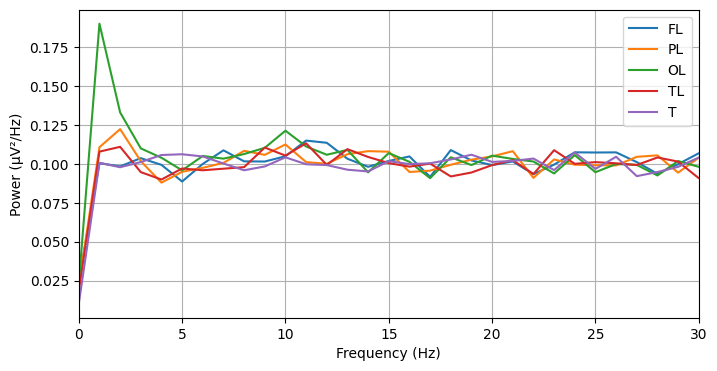

In [27]:
from macro_eeg.viz import plot_power

fig, ax = plt.subplots(figsize=(8, 4))

fig, ax = plot_power(
    freqs=freqs,
    power=power,
    index_to_lbl=index_to_lbl,
    ax=ax
)